In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import math, joblib

import tensorflow as tf
from tensorflow.keras.models import load_model

# -----------------------------
# 1. Load and Preprocess Data
# -----------------------------

# Load the caliper data
df = pd.read_csv('data/experiment2_caliper.csv')

# Load the experimental speeds data
speeds_df = pd.read_csv('model/experiment_2.csv')

# Merge the two datasets.
# We assume that the 'layer_width_intended' in df corresponds to 'layer_width' in speeds_df.
df_merged = df.merge(speeds_df, left_on=["extrusion", "layer_height", "layer_width_intended"],
                     right_on=["extrusion", "layer_height", "layer_width"],
                     how="left")
# Remove the redundant 'layer_width' column from speeds_df
df_merged.drop(columns=["layer_width"], inplace=True)

# Assign experimental speed based on model type:
# If nn-formula is 0 (Neural Network), use nn_speed; if 1 (Analytical), use formula_speed.
# df_merged['exp_speed'] = df_merged.apply(
#     lambda row: row['nn_speed'] if row['nn-formula'] == 0 else row['formula_speed'], axis=1
# )

df_merged['exp_speed'] = df_merged.apply(
    lambda row: row['formula_speed'] if row['nn-formula'] == 0 else row['formula_speed'], axis=1
)

df_merged = df_merged.drop(['nn_speed', 'formula_speed'], axis=1)

df_merged.to_csv("data/experiment_2_merged.csv", index=False)
df_merged.head()

,pallet,extrusion,layer_height,nn-formula,line,layer_width_intended,replicate,layer_width_measured,over-under,exp_speed
0,SA1,2,5,0,1,18,1,-1.0,-1,394
1,SA1,2,5,0,1,18,2,-1.0,-1,394
2,SA1,2,5,0,1,18,3,-1.0,-1,394
3,SA1,2,5,0,1,18,4,-1.0,-1,394
4,SA1,2,5,0,1,18,5,-1.0,-1,394


In [2]:
df_merged = df_merged[df_merged['layer_width_measured'] != -1]

# Compute error metrics for layer width
df_merged['error'] = df_merged['layer_width_measured'] - df_merged['layer_width_intended']
df_merged['abs_error'] = df_merged['error'].abs()
df_merged['squared_error'] = df_merged['error'] ** 2
df_merged['relative_error'] = df_merged['abs_error'] / df_merged['layer_width_intended']

In [3]:
group_cols = ['extrusion', 'layer_height', 'nn-formula', 'line']

# Calculate the group average for 'layer_width_measured'
df_merged['line_avg'] = df_merged.groupby(group_cols)['layer_width_measured'].transform('mean')

# Create a new column that is the difference between the measured value and the group average
df_merged['error-mean'] = df_merged['layer_width_measured'] - df_merged['line_avg']

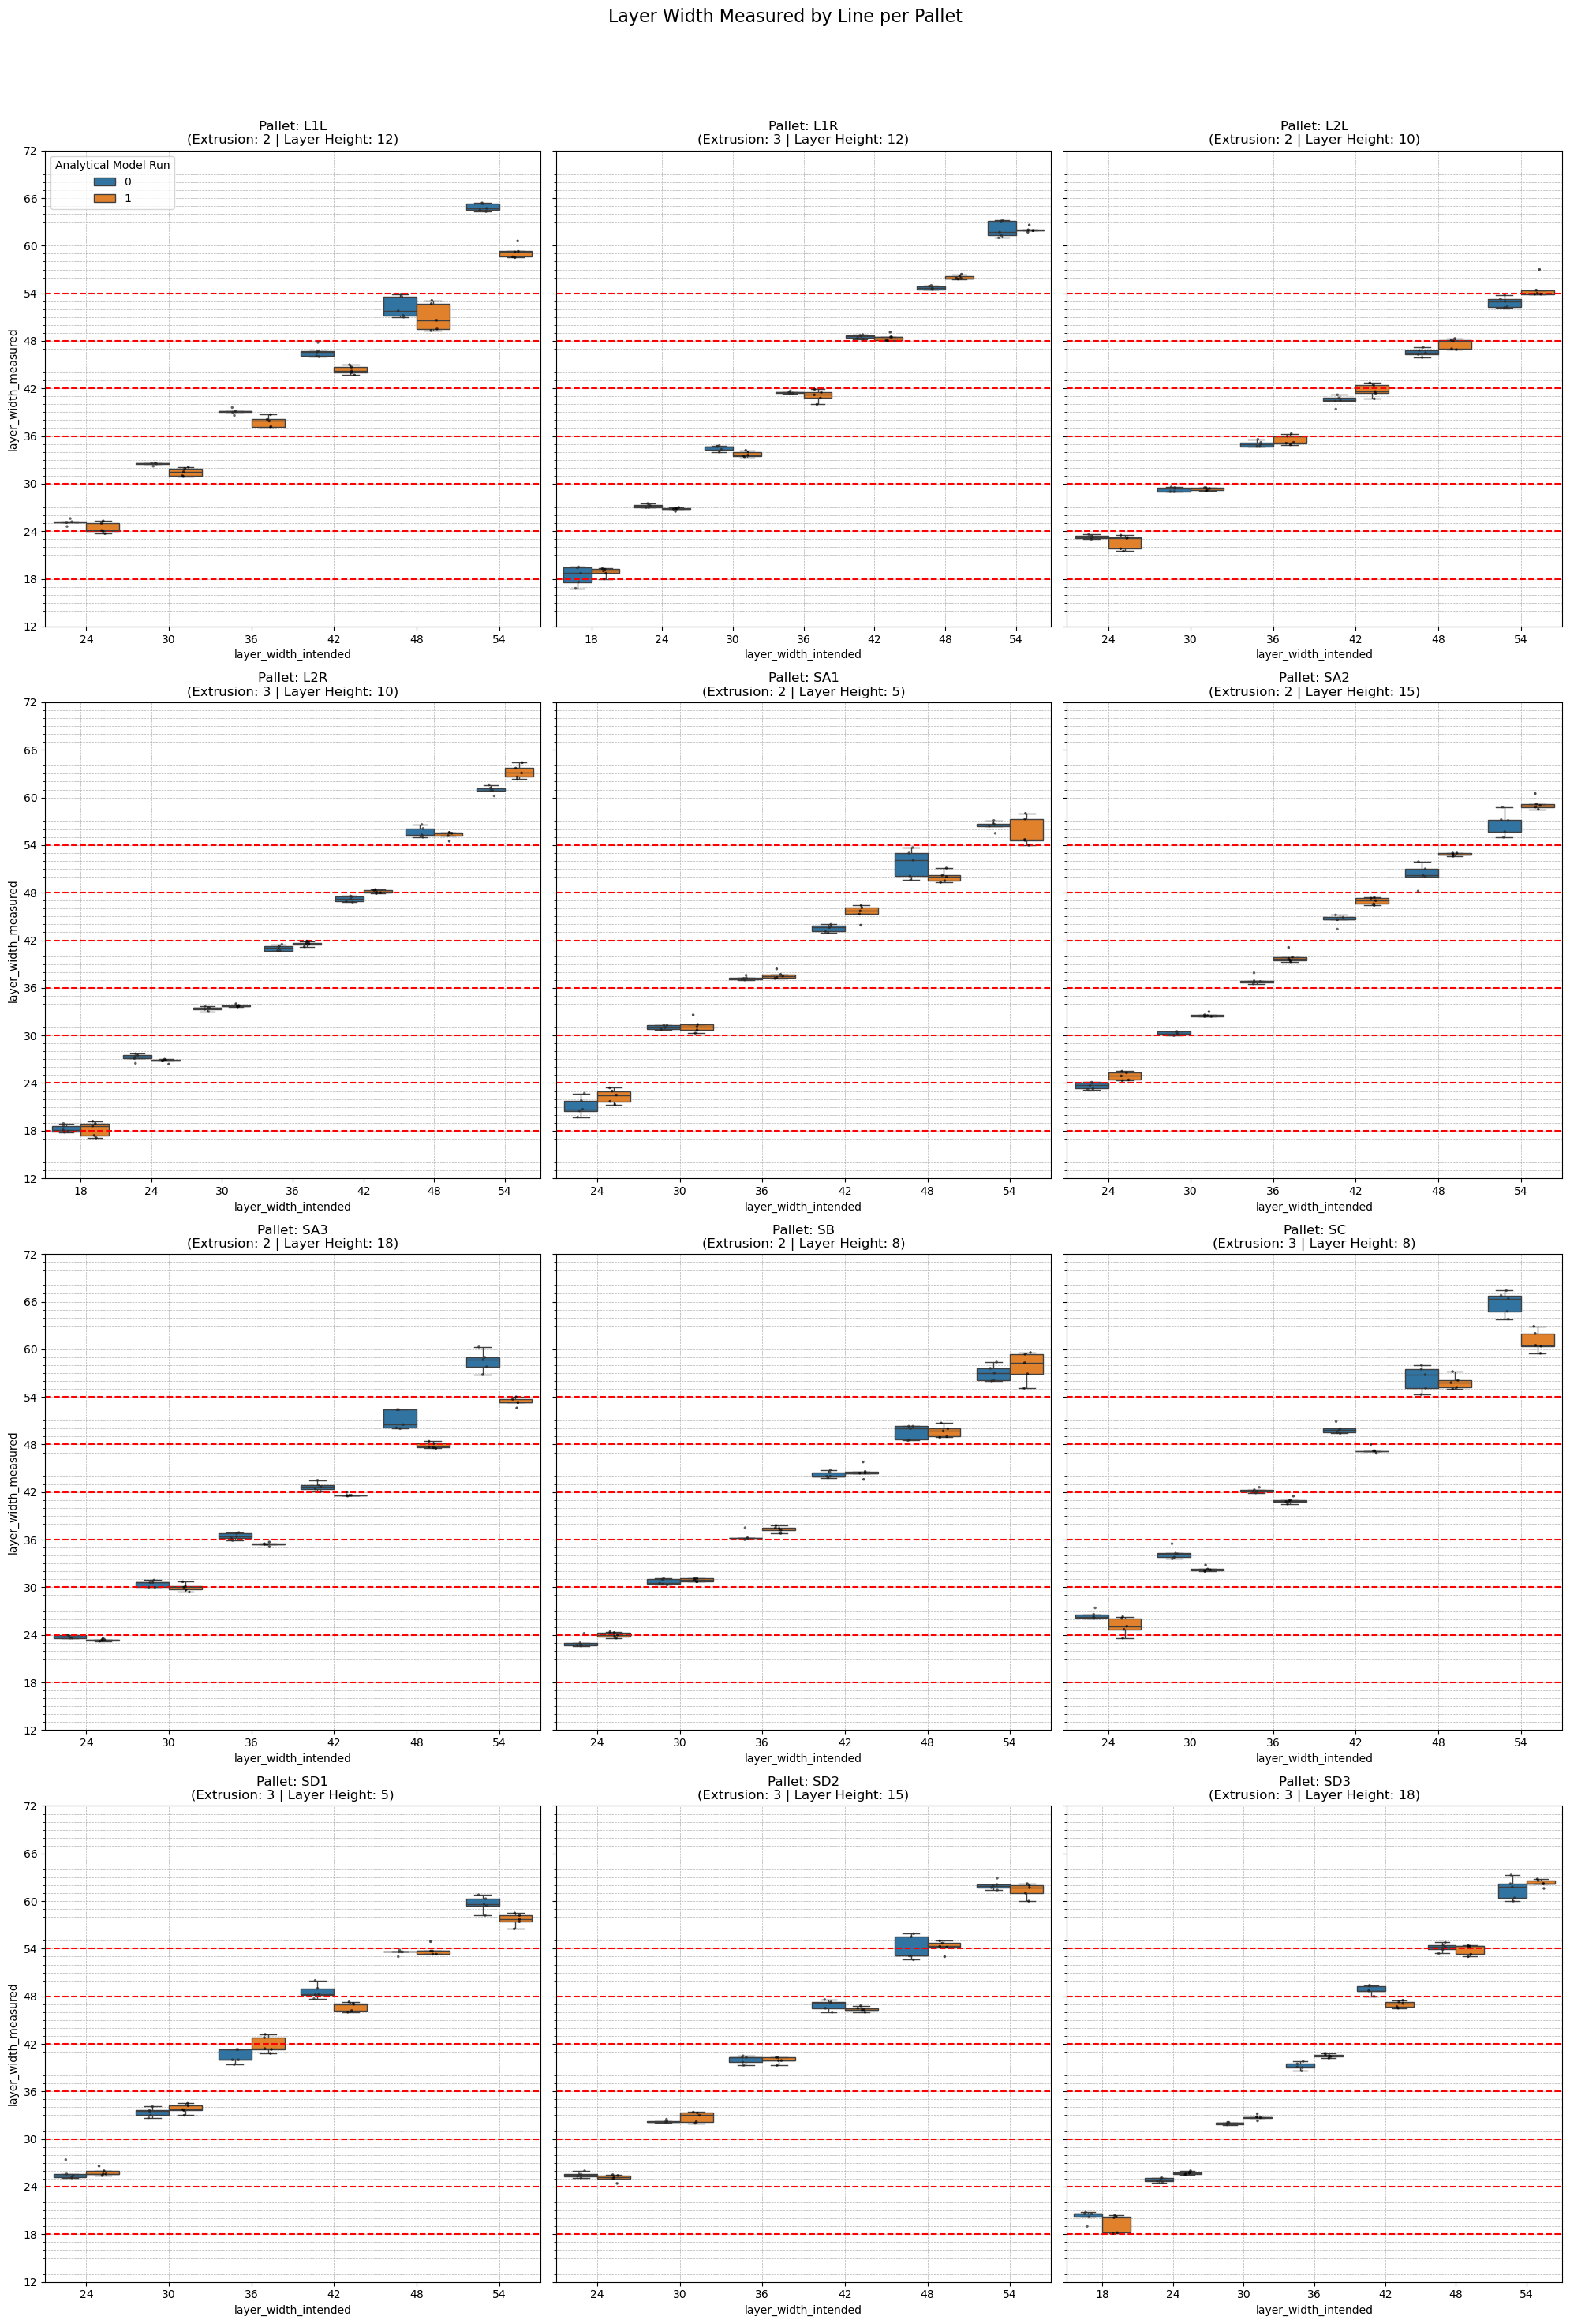

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator

# Example: Assuming df_merged is already loaded with your data.
# Clean the pallet names by removing '*' characters.
df_merged['pallet'] = df_merged['pallet'].astype(str).str.replace('*', '', regex=False)
df_merged['layer_width_intended'] = pd.to_numeric(df_merged['layer_width_intended'], errors='coerce')
df_merged['layer_width_measured'] = pd.to_numeric(df_merged['layer_width_measured'], errors='coerce')
df_merged['extrusion'] = pd.to_numeric(df_merged['extrusion'], errors='coerce')
df_merged['layer_height'] = pd.to_numeric(df_merged['layer_height'], errors='coerce')

# Get sorted unique pallets.
unique_pallets = sorted(df_merged['pallet'].unique())

# Create a 4x3 grid of subplots.
fig, axes = plt.subplots(4, 3, figsize=(20, 30), sharey=True)
axes = axes.flatten()

# Iterate through each unique pallet and plot in its corresponding subplot.
for i, pallet in enumerate(unique_pallets):
    ax = axes[i]
    sub_df = df_merged[df_merged['pallet'] == pallet]
    
    # Draw the boxplot: x is 'layer_width_intended' and group by 'nn-formula' (via hue)
    sns.boxplot(
        data=sub_df,
        x='layer_width_intended',
        y='layer_width_measured',
        hue='nn-formula',
        ax=ax,
        showfliers=False  # hide outliers for clarity
    )
    
    # Overlay individual data points with a slight horizontal dodge.
    sns.stripplot(
        data=sub_df,
        x='layer_width_intended',
        y='layer_width_measured',
        hue='nn-formula',
        dodge=True,
        marker='.',
        palette='dark:black',
        ax=ax,
        alpha=0.7
    )
    
    # Create the set of unique intended layer widths, ensuring 18 is always included.
    unique_intended = sorted(set(df_merged['layer_width_intended'].unique()).union({18}))
    for intended in unique_intended:
        ax.axhline(y=intended, color='red', linestyle='--')
    
    # Set y-axis grid lines: major ticks every 6 units, minor ticks every 1 unit.
    ax.yaxis.set_major_locator(MultipleLocator(6))
    ax.yaxis.set_minor_locator(MultipleLocator(1))

    ax.set_ylim(12, 72)
    
    # Extract extrusion and layer height (assuming they're the same for the entire pallet)
    if not sub_df.empty:
        extrusion = sub_df['extrusion'].iloc[0]
        layer_height = sub_df['layer_height'].iloc[0]
    else:
        extrusion = 'N/A'
        layer_height = 'N/A'
    
    # Set subplot title with pallet, extrusion, and layer height.
    ax.set_title(f"Pallet: {pallet}\n(Extrusion: {extrusion} | Layer Height: {layer_height})")
    
    # Remove duplicate legends; only keep legend in the first subplot.
    if i != 0:
        ax.get_legend().remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        n_nn = len(sub_df['nn-formula'].unique())
        ax.legend(handles[:n_nn], labels[:n_nn], title='Analytical Model Run')
    
    # Add grid lines for clarity.
    ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

# Turn off any unused subplots.
for j in range(len(unique_pallets), len(axes)):
    axes[j].axis('off')

fig.suptitle("Layer Width Measured by Line per Pallet", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [5]:
# -----------------------------
# 2. Compute and Print Error Metrics
# -----------------------------

# Overall layer width error metrics
overall_mae = df_merged['abs_error'].mean()
overall_mse = df_merged['squared_error'].mean()
overall_rmse = overall_mse ** 0.5

print("Overall Layer Width Error Metrics:")
print("MAE:", overall_mae)
print("MSE:", overall_mse)
print("RMSE:", overall_rmse)

# Group by model type ('nn-formula': 0 = Neural Network, 1 = Analytical Model)
model_metrics = df_merged.groupby('nn-formula').agg(
    count=('error', 'count'),
    mean_error=('error', 'mean'),
    std_error=('error', 'std'),
    mean_abs_error=('abs_error', 'mean'),
    std_abs_error=('abs_error', 'std'),
    mean_squared_error=('squared_error', 'mean'),
    rmse=('squared_error', lambda x: (x.mean())**0.5),
    mean_relative_error=('relative_error', 'mean')
)
print("\nError Metrics by Model Type:")
model_metrics

Overall Layer Width Error Metrics:
MAE: 3.4093333333333335
MSE: 18.45992
RMSE: 4.296500901896798

Error Metrics by Model Type:


,count,mean_error,std_error,mean_abs_error,std_abs_error,mean_squared_error,rmse,mean_relative_error
nn-formula,,,,,,,,
0,375,3.225867,3.097713,3.528267,2.747347,19.976453,4.469503,0.087895
1,375,3.069600,2.746098,3.290400,2.476491,16.943387,4.116235,0.082680


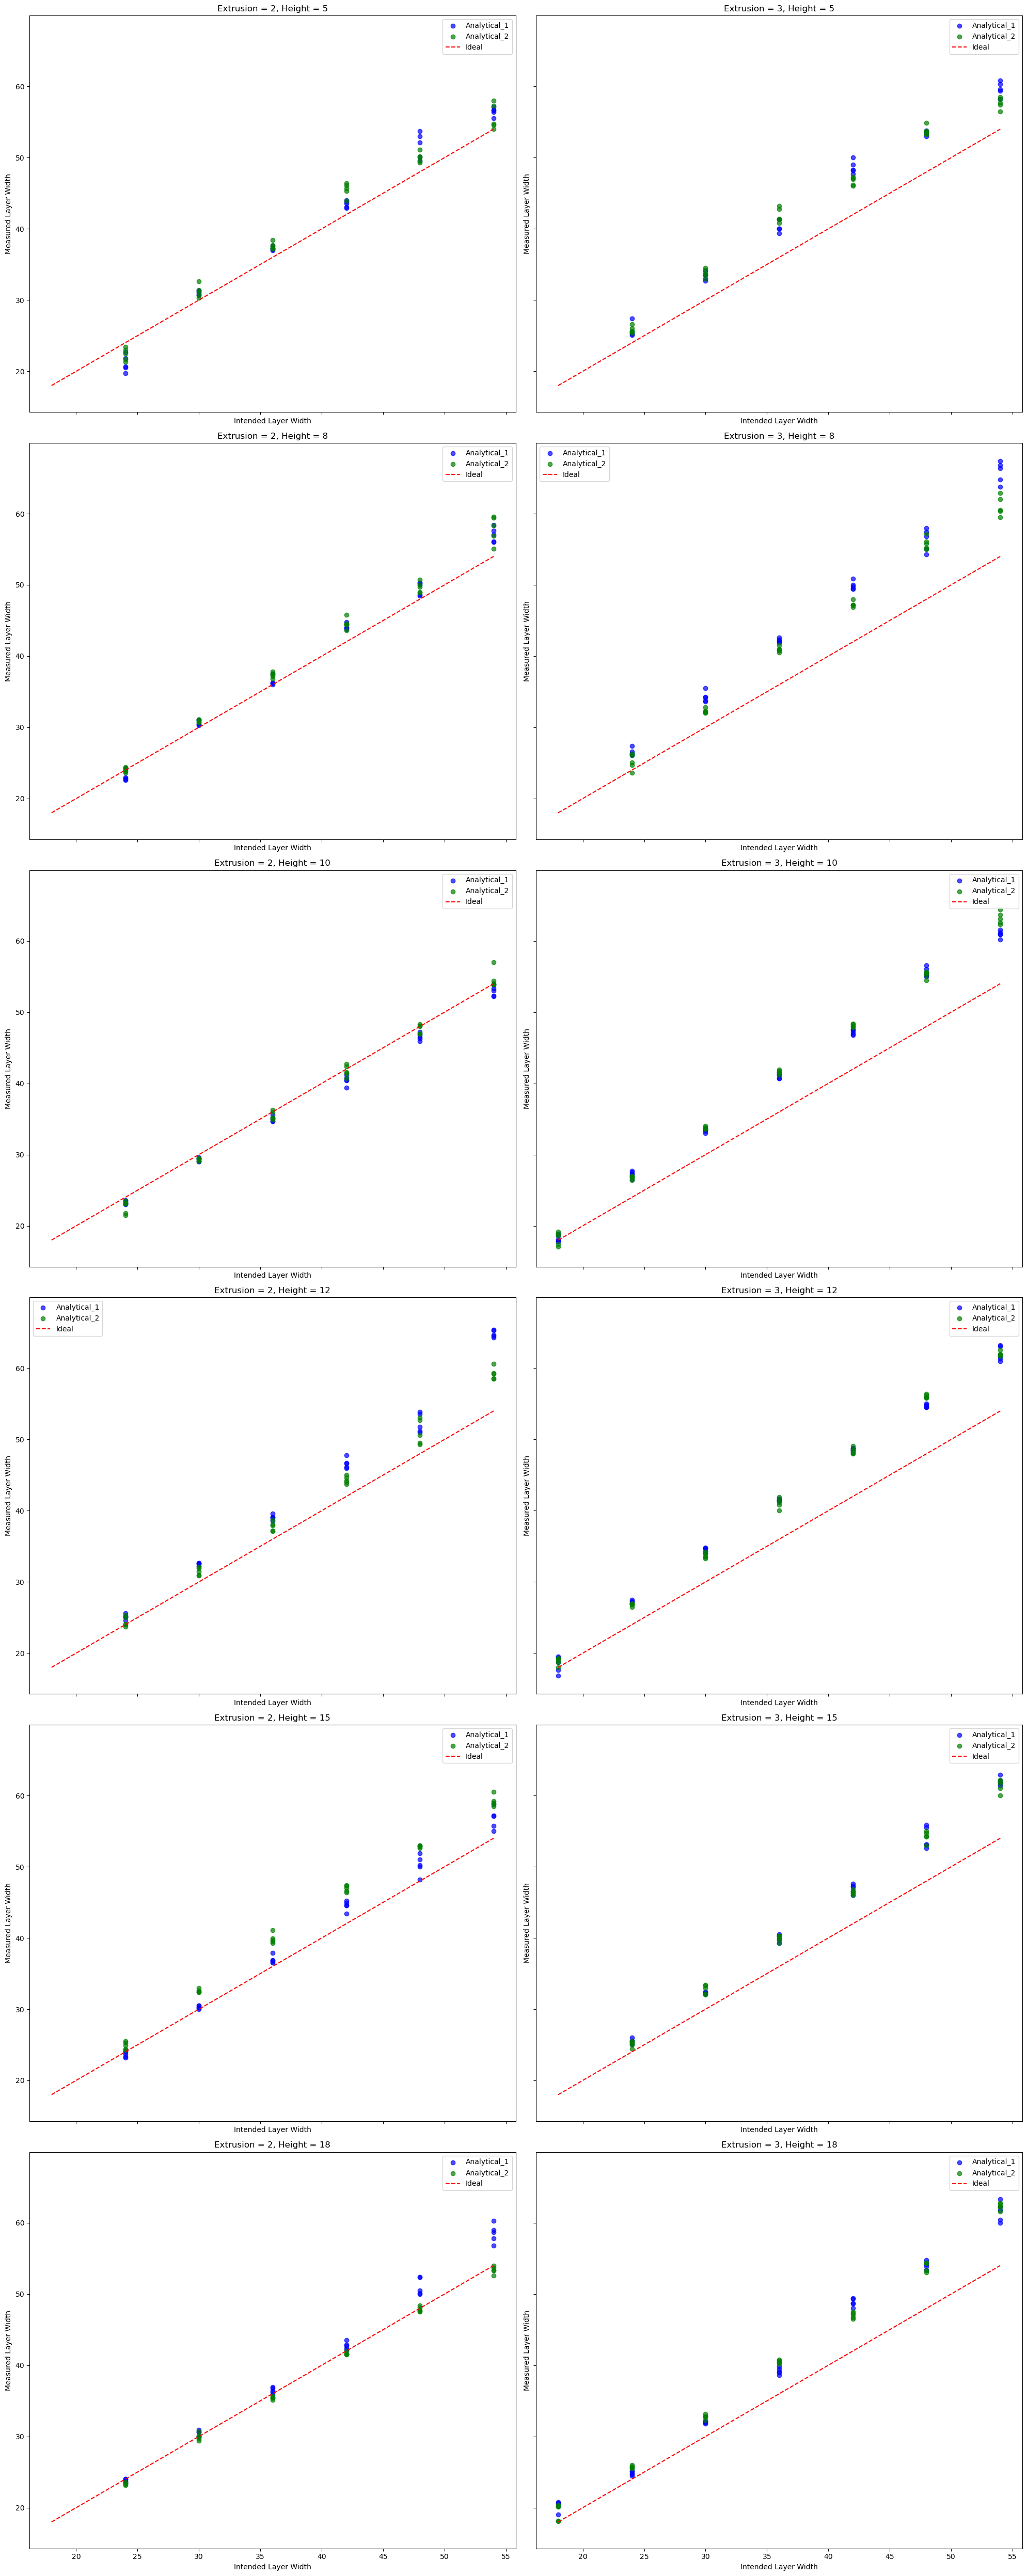

In [6]:
# Get unique extrusion speeds and layer heights
unique_extrusions = sorted(df_merged['extrusion'].unique())
unique_heights = sorted(df_merged['layer_height'].unique())

n_cols = len(unique_extrusions)  # each column is an extrusion speed
n_rows = len(unique_heights)     # each row is a layer height

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 50), sharex=True, sharey=True)

# Loop over each combination of layer height and extrusion
for i, lh in enumerate(unique_heights):
    for j, extr in enumerate(unique_extrusions):
        # Get the current axis
        # When there's only one row or column, axes may be a 1D array
        ax = axes[i, j] if n_rows > 1 and n_cols > 1 else (axes[j] if n_rows == 1 else axes[i])
        
        # Filter the data for the current layer height and extrusion speed
        subset = df_merged[(df_merged['layer_height'] == lh) & (df_merged['extrusion'] == extr)]
        
        # Plot data for each model type
        for model, color, label in zip([0, 1], ['blue', 'green'], ['Analytical_1', 'Analytical_2']):
            subsubset = subset[subset['nn-formula'] == model]
            ax.scatter(
                subsubset['layer_width_intended'], 
                subsubset['layer_width_measured'],
                alpha=0.7, label=label, color=color
            )
        
        # Plot the ideal reference line (measured equals intended)
        # Here, we use the global min and max for consistency
        global_min = df_merged['layer_width_intended'].min()
        global_max = df_merged['layer_width_intended'].max()
        ax.plot([global_min, global_max], [global_min, global_max],
                color='red', linestyle='--', label='Ideal')
        
        ax.set_xlabel('Intended Layer Width')
        ax.set_ylabel('Measured Layer Width')
        ax.set_title(f'Extrusion = {extr}, Height = {lh}')
        ax.legend()

plt.tight_layout()
plt.show()

2025-07-08 15:10:29.792079: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-07-08 15:10:29.792109: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-07-08 15:10:29.792113: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-07-08 15:10:29.792141: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-08 15:10:29.792163: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-07-08 15:10:30.148280: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-07-08 15:10:30.150843:

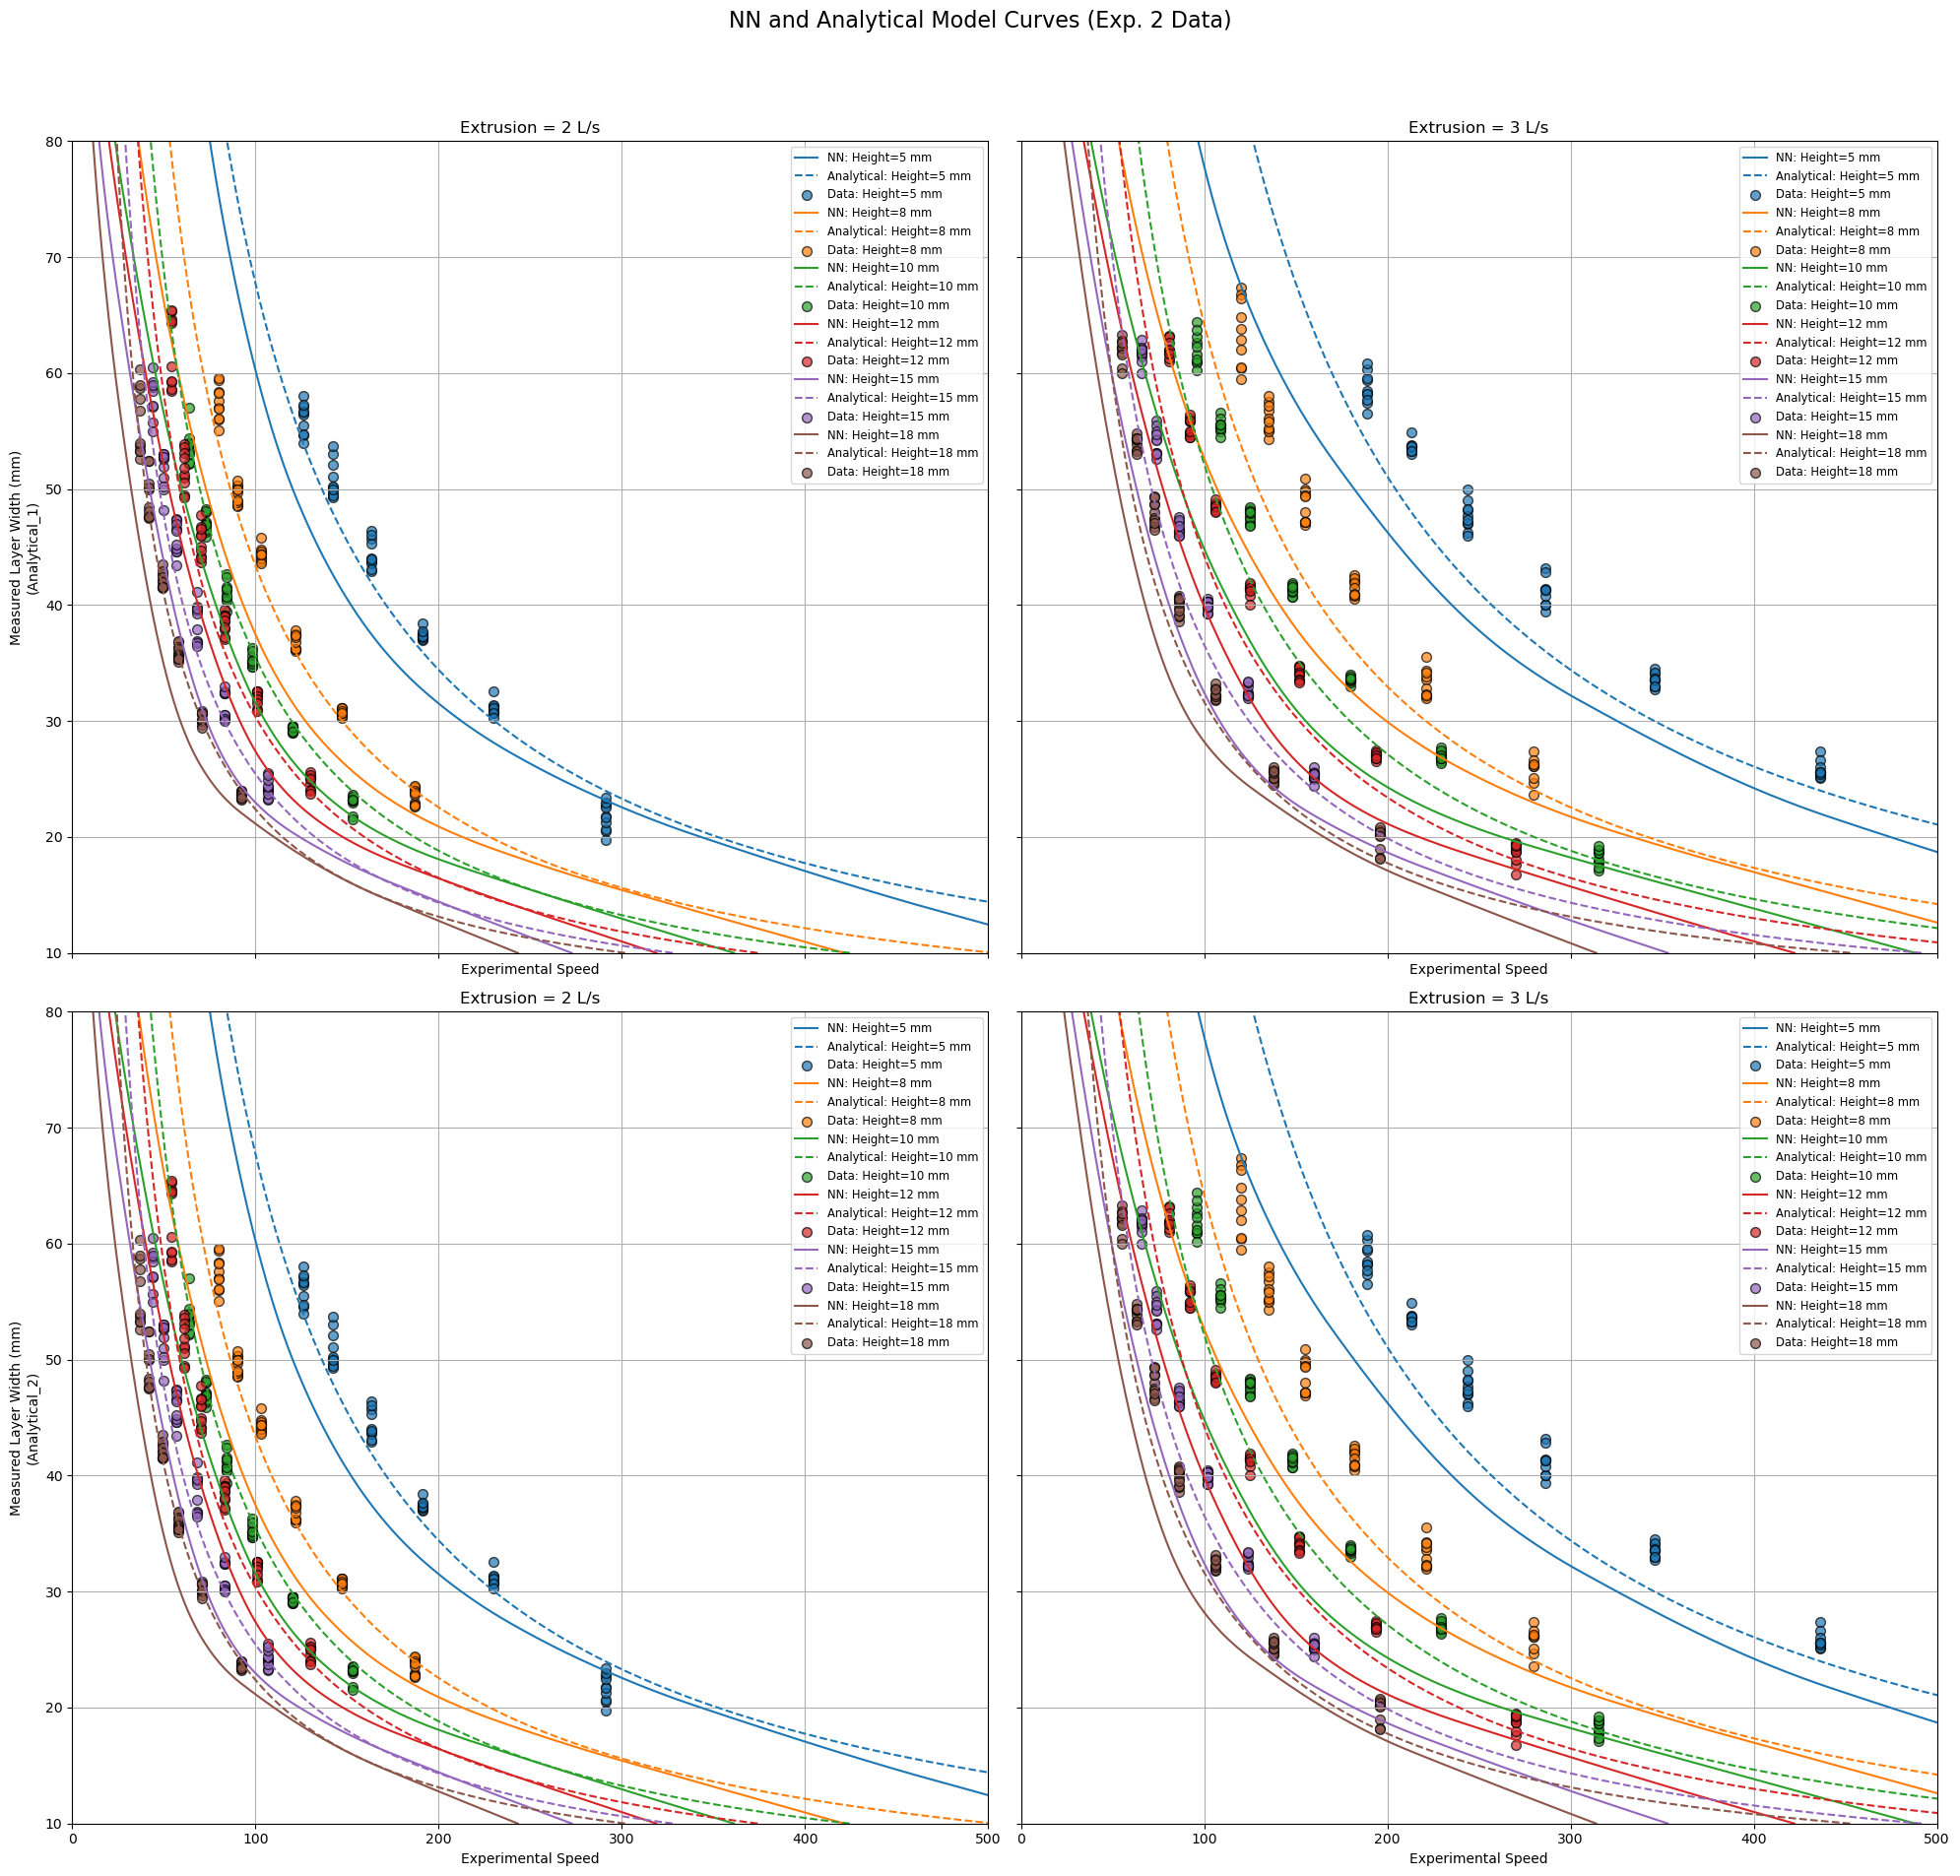

In [7]:
def plot_model_curves_with_data(
    nn_model,
    scaler,
    data_points,
    main_heights=[5, 8, 10, 12, 15],
    extrusions=[2, 3],
    w_min=10,
    w_max=80,
    w_points=1000
):
    """
    For each extrusion value and for each model type (based on nn-formula: 0 or 1), this function:
      1. Generates a range of layer widths (w_min to w_max).
      2. For each specified layer height, it computes:
           - The NN model predictions using the provided nn_model and scaler.
           - The Analytical model predictions via a math formula:
                 speed = (extrusion * 1e6) / (60 * ((width * height) - (height**2) + ((height**2)*pi/4)))
      3. Plots both prediction curves (solid for NN, dashed for Analytical) in a consistent color.
      4. Overlays the actual experimental data points for the matching extrusion, layer height, and nn-formula type.
      
    The plot shows experimental speed on the X‑axis and measured layer width on the Y‑axis.
    The grid is broken into two rows:
       - Row 0: nn-formula == 0 (Neural Network)
       - Row 1: nn-formula == 1 (Analytical)
    """
    # Generate a range of widths using the provided limits.
    widths = np.linspace(w_min, w_max, w_points)
    
    n_extrusions = len(extrusions)
    n_model_types = 2  # nn-formula values: 0 and 1
    fig, axes = plt.subplots(n_model_types, n_extrusions, 
                             figsize=(10 * n_extrusions, 10 * n_model_types), 
                             sharex=True, sharey=True)
    
    # Ensure axes is 2D if only one extrusion is provided.
    if n_extrusions == 1:
        axes = axes.reshape(n_model_types, 1)
    
    # Loop over model types and extrusions.
    for row_idx, model_type in enumerate([0, 1]):
        for col_idx, extr in enumerate(extrusions):
            ax = axes[row_idx, col_idx]
            # For each specified layer height, compute predictions and overlay data.
            for i, h in enumerate(main_heights):
                color = f"C{i}"
                # -----------------------------
                # 1. NN Model Prediction Curve
                # -----------------------------
                # Build an input array with columns: layer_height, layer_width, extrusion.
                X = np.column_stack([
                    np.full_like(widths, h),
                    widths,
                    np.full_like(widths, extr)
                ])
                # Create a DataFrame with the expected feature names.
                X_df = pd.DataFrame(X, columns=["layer_height", "layer_width", "extrusion"])
                X_df = X_df[scaler.feature_names_in_]
                
                # Scale and predict using the NN model.
                X_scaled = scaler.transform(X_df)
                nn_pred_speed = nn_model.predict(X_scaled, verbose=0).flatten()
                
                # Plot the NN prediction curve (solid line).
                ax.plot(nn_pred_speed, widths, label=f"NN: Height={h} mm", color=color)
                
                # -----------------------------
                # 2. Analytical Model Prediction Curve
                # -----------------------------
                anal_pred_speed = (extr * 1e6) / (60 * ((widths * h) - (h**2) + ((h**2) * np.pi / 4)))
                ax.plot(anal_pred_speed, widths, linestyle='--', label=f"Analytical: Height={h} mm", color=color)
                
                # -----------------------------
                # 3. Overlay Actual Data Points
                # -----------------------------
                # Filter experimental data for current extrusion, layer height, and model type.
                subset = data_points[
                    (data_points["extrusion"] == extr) &
                    (data_points["layer_height"] == h) #&
                    #(data_points["nn-formula"] == model_type)
                ]
                if not subset.empty:
                    ax.scatter(subset['exp_speed'], subset['layer_width_measured'],
                               color=color, edgecolor='black', alpha=0.7, s=50,
                               label=f"Data: Height={h} mm")
            
            ax.set_xlabel("Experimental Speed")
            ax.set_title(f"Extrusion = {extr} L/s")
            ax.grid(True)
            ax.set_xlim(0, 500)
            ax.set_ylim(w_min, w_max)
            ax.legend(fontsize='small')
            
            # For the first column, add a ylabel that indicates the model type.
            if col_idx == 0:
                if model_type == 0:
                    ax.set_ylabel("Measured Layer Width (mm)\n(Analytical_1)")
                else:
                    ax.set_ylabel("Measured Layer Width (mm)\n(Analytical_2)")
                    
    fig.suptitle("NN and Analytical Model Curves (Exp. 2 Data)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Load the neural network model and scaler.
nn = load_model("model/3DCP_wANN_model.keras")
scaler = joblib.load("model/3DCP_wANN_scaler.pkl")

# Example usage:
# (Ensure that nn, scaler, and df_merged are already defined in your notebook)
plot_model_curves_with_data(
    nn_model=nn,
    scaler=scaler,
    data_points=df_merged,
    main_heights=[5, 8, 10, 12, 15, 18],
    extrusions=[2, 3]
)